In [271]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dense,Input , Flatten , Dropout , BatchNormalization , ReLU, Conv2D, MaxPool2D, GlobalAvgPool2D , RandomFlip , RandomZoom , SpatialDropout2D,RandomRotation, GlobalAveragePooling2D, Rescaling, Activation, RandomTranslation,RandomContrast ,RandomBrightness, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam , SGD
from tensorflow.keras.regularizers import l2 , l1
from tensorflow.keras.datasets import mnist , fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau, ModelCheckpoint


from tensorflow.keras.losses import categorical_crossentropy, binary_crossentropy, binary_focal_crossentropy,categorical_focal_crossentropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score, roc_curve,auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.datasets import load_iris , make_classification
from tensorflow.keras.utils import to_categorical , image_dataset_from_directory
import os

In [272]:
# ── Hyperparameters ──────────────────────────────────────────
SEED             = 42
IMG_SIZE         = (224, 224)
BATCH_SIZE       = 64       # Use 32 if your machine has a strong GPU
VAL_SPLIT        = 0.30
HEAD_EPOCHS      = 10
FINE_TUNE_EPOCHS = 40


# ── Reproducibility ──────────────────────────────────────────
keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [273]:
from pathlib import Path

DATASET_DIR = Path("/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset")

train_path = DATASET_DIR / "Training"
test_path = DATASET_DIR / "Testing"


In [274]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

val_ds = keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

test_ds = keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)
class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)
print(num_classes)

print("Keras class order:", train_ds.class_names)
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

val_ds = val_ds.cache().prefetch(AUTOTUNE)

test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("Datasets ready ✅")



Found 5600 files belonging to 4 classes.
Using 3920 files for training.
Found 5600 files belonging to 4 classes.
Using 1680 files for validation.
Found 1600 files belonging to 4 classes.
['glioma', 'meningioma', 'notumor', 'pituitary']
4
Keras class order: ['glioma', 'meningioma', 'notumor', 'pituitary']
Datasets ready ✅


In [275]:
def count_images(folder):
    """Count all image files in a folder."""
    total = 0
    for pattern in ["*.jpg", "*.jpeg", "*.png", "*.bmp"]:
        total += len(list(folder.glob(pattern)))
    return total

print("Training images:")
for name in class_names:
    print(f"  {name}: {count_images(train_path / name)}")

print("\nTesting images:")
for name in class_names:
    print(f"  {name}: {count_images(test_path / name)}")

Training images:
  glioma: 1400
  meningioma: 1400
  notumor: 1400
  pituitary: 1400

Testing images:
  glioma: 400
  meningioma: 400
  notumor: 400
  pituitary: 400


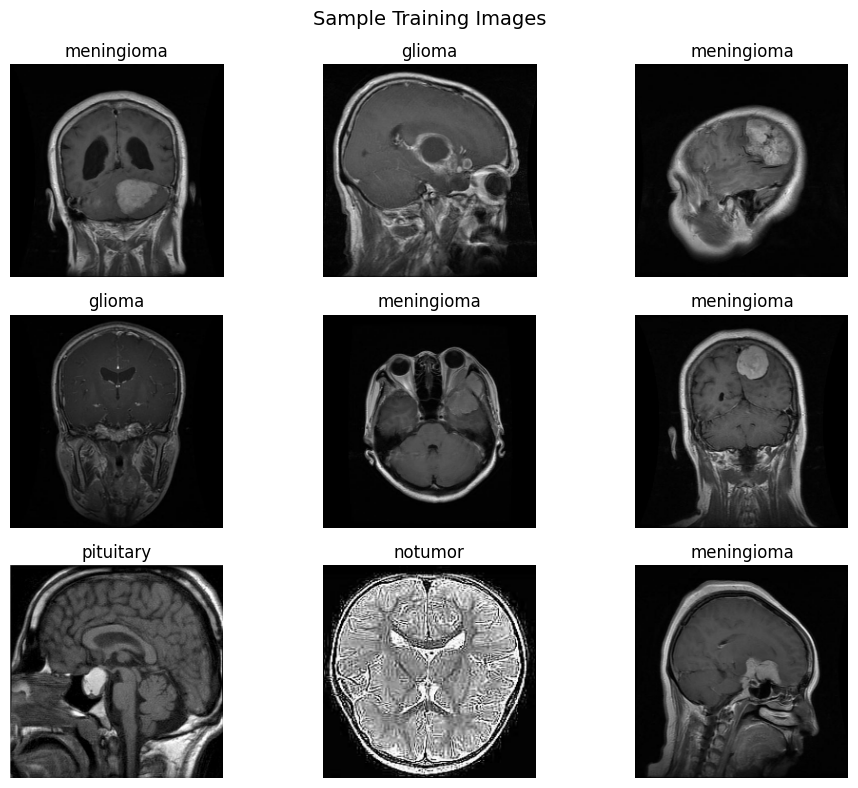

In [276]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_index = np.argmax(labels[i].numpy())
        plt.title(class_names[label_index])
        plt.axis("off")

plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()

In [277]:
data_augmentation = keras.Sequential([
    RandomRotation(0.04),
    RandomZoom(0.08),
    RandomTranslation(0.03, 0.03),
    RandomContrast(0.10),
    RandomBrightness(0.08),
], name="data_augmentation")

In [278]:


inputs = keras.Input(shape=IMG_SIZE + (3,))

x = Rescaling(1./255)(inputs)
# Data Augmentation
# x = data_augmentation(x)
from tensorflow.keras.layers import Add

# Save input
shortcut = x

shortcut = Conv2D(
    32,
    (1,1),
    padding="same",
    use_bias=False,
    kernel_initializer="he_normal"
)(shortcut)

shortcut = BatchNormalization()(shortcut)
x = keras.layers.Activation("swish")(x)

x = Conv2D(
    32,
    (3,3),
    padding="same",
    use_bias=False,
    kernel_initializer="he_normal",
    kernel_regularizer=regularizers.l2(1e-5)
)(x)
x = BatchNormalization()(x)

# Skip connection
x = Add()([x, shortcut])

# Activation after addition
x = keras.layers.Activation("swish")(x)

x = MaxPooling2D((2,2))(x)

x = Conv2D(
    64,
    (3,3),
    padding="same",
    activation="swish",
    kernel_initializer="he_normal",
    kernel_regularizer=regularizers.l2(1e-5))(x)
x = Conv2D(
    64,
    (3,3),
    padding="same",
    use_bias=False,
    kernel_initializer="he_normal",
    kernel_regularizer=regularizers.l2(1e-5)
)(x)

x = BatchNormalization()(x)
x = keras.layers.Activation("swish")(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.20)(x)

# ==========================
# Block 2
# ==========================

x = Conv2D(
    128,
    (3,3),
    padding="same",
    activation="swish",
    kernel_initializer="he_normal",
    kernel_regularizer=regularizers.l2(1e-5)
)(x)
x = Conv2D(
    128,
    (3,3),
    padding="same",
    use_bias=False,
    kernel_initializer="he_normal",
    kernel_regularizer=regularizers.l2(1e-5)
)(x)

x = BatchNormalization()(x)
x = keras.layers.Activation("swish")(x)


x = MaxPooling2D((2,2))(x)
x = Dropout(0.25)(x)


x = Flatten()(x)

x = Dropout(0.40)(x)


x = Dense(
    128,
    activation="swish",
    kernel_initializer="he_normal",
    kernel_regularizer=regularizers.l2(1e-5)
)(x)
x = BatchNormalization()(x)
x = Dropout(0.20)(x)




outputs = Dense(
    num_classes,
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_22        │ (None, 224, 224,  │          0 │ input_layer_21[0… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_76       │ (None, 224, 224,  │          0 │ rescaling_22[0][… │
│ (Activation)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_116 (Conv2D) │ (None, 224, 224,  │        864 │ activation_76[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_115 (Conv2D) │ (None, 224, 224,  │         96 │ rescaling_22[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_116[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_115[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_22 (Add)        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_77       │ (None, 224, 224,  │          0 │ add_22[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_55    │ (None, 112, 112,  │          0 │ activation_77[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_117 (Conv2D) │ (None, 112, 112,  │     18,496 │ max_pooling2d_55… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_118 (Conv2D) │ (None, 112, 112,  │     36,864 │ conv2d_117[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_118[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_78       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_56    │ (None, 56, 56,    │          0 │ activation_78[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_78          │ (None, 56, 56,    │          0 │ max_pooling2d_56… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_119 (Conv2D) │ (None, 56, 56,    │     73,856 │ dropout_78[0][0]

 Total params: 13,124,868 (50.07 MB)

 Trainable params: 13,124,100 (50.06 MB)

 Non-trainable params: 768 (3.00 KB)

In [279]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0012),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_head = [
  
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        
        factor=0.1,
        patience=3,
        
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        
        patience=10,
        
        verbose=1,
    ),
]

print("Model compiled ✅  |  Phase 1 callbacks ready ✅")

Model compiled ✅  |  Phase 1 callbacks ready ✅


In [280]:
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks_head,
    
)

Epoch 1/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 26s 263ms/step - accuracy: 0.7500 - loss: 0.6744 - val_accuracy: 0.3560 - val_loss: 1.7002 - learning_rate: 0.0012
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.8625 - loss: 0.3898 - val_accuracy: 0.5631 - val_loss: 0.9594 - learning_rate: 0.0012
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.9099 - loss: 0.2648 - val_accuracy: 0.7798 - val_loss: 0.6423 - learning_rate: 0.0012
Epoch 4/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - accuracy: 0.9406 - loss: 0.2002 - val_accuracy: 0.5506 - val_loss: 1.4095 - learning_rate: 0.0012
Epoch 5/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.9477 - loss: 0.1669 - val_accuracy: 0.4720 - val_loss: 3.1598 - learning_rate: 0.0012
Epoch 6/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9613 - loss: 0.1484
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00012000000569969416.
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.9625 - loss: 0.1402 -

In [ ]:
tl_loss, tl_acc = model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Loss     : {tl_loss:.4f}")
print(f"Test Accuracy : {tl_acc:.4f}")


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.8913 - loss: 0.6001
Test Loss     : 0.6001
Test Accuracy : 0.8913


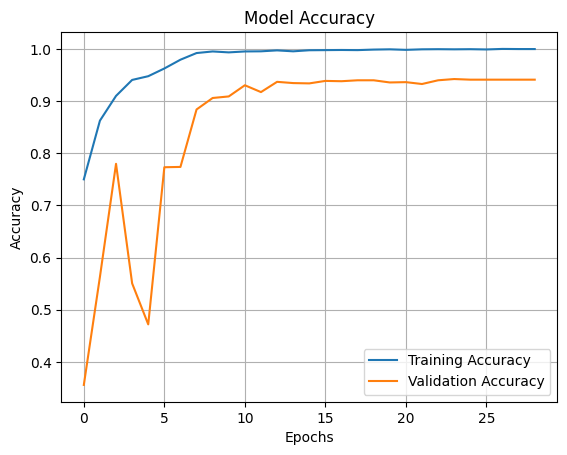

In [282]:
plt.plot(history_head.history['accuracy'],label='Training Accuracy')
plt.plot(history_head.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid()
plt.show()

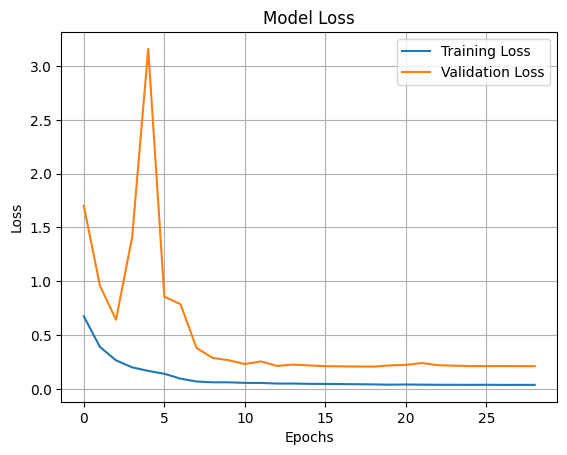

In [283]:
plt.plot(history_head.history['loss'],label='Training Loss')
plt.plot(history_head.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid()
plt.show()